# 03bis — Où le sentiment cesse d'anticiper et commence à décrire

**La question.** À quelle heure de la nuit le sentiment cesse-t-il de prédire le gap d'ouverture pour se
mettre à le décrire ?

**L'hypothèse.** La séance de pré-ouverture américaine ouvre à **4h00** heure de New York. Avant cette
heure, il ne se négocie quasiment rien (l'*after-hours* s'arrête à 20h00). Après, les prix bougent
réellement et le prix d'ouverture de 9h30 commence à se former.

**Le test.** On calcule la corrélation entre le sentiment cumulé depuis 16h00 et le gap d'ouverture, pour
une série d'heures de coupure. Si l'hypothèse est vraie, la courbe est plate jusqu'à 4h00 puis décolle.

**L'enjeu.** Ce notebook détermine la coupure retenue pour l'ensemble du mémoire. Ce choix devient
**mesuré** au lieu d'être conventionnel.

In [13]:
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["figure.figsize"] = (13, 6)

m = pd.read_parquet(os.path.join(DATA, "MESSAGES_HORODATES.parquet"))
m["ts_ny"] = pd.to_datetime(m["ts_ny"])
CALENDRIER = pd.read_parquet(os.path.join(DATA, "CALENDRIER_BOURSE.parquet"))["Date"].values
CALENDRIER = np.sort(CALENDRIER.astype("datetime64[ns]"))

PANEL = os.path.join(DATA, "PANEL_SENTIMENT_WINDOWS_2020_2022_v2.csv")
prix = pd.read_csv(PANEL, usecols=["Date", "Ticker", "gap", "ret_oc", "ret_cc"])
prix["Date"] = pd.to_datetime(prix["Date"])

print(f"{len(m):,} messages | {len(CALENDRIER)} jours de bourse | {len(prix):,} lignes de panel")

3,711,333 messages | 607 jours de bourse | 2,740 lignes de panel


## 1 — Rattacher chaque message à sa nuit cible

Un message appartient à la nuit qui précède le **prochain jour de bourse dont l'ouverture suit le
message**. Un message du vendredi 18h00 appartient donc à la nuit du lundi : c'est ce lundi-là que son
information sera incorporée au prix d'ouverture.

In [14]:
ts = m["ts_ny"].values.astype("datetime64[ns]")

OUVERTURES = CALENDRIER + np.timedelta64(9 * 60 + 30, "m")   # 9h30
CLOTURES   = CALENDRIER + np.timedelta64(16 * 60, "m")       # 16h00

# Premier jour de bourse dont l'ouverture est STRICTEMENT après le message
idx = np.searchsorted(OUVERTURES, ts, side="right")
valide = idx < len(CALENDRIER)
m = m.loc[valide].copy()
idx = idx[valide]

m["date_cible"]   = CALENDRIER[idx]
m["cloture_prec"] = np.where(idx > 0, CLOTURES[np.maximum(idx - 1, 0)],
                             np.datetime64("NaT"))

# On ne garde que les messages NOCTURNES
m = m[m["ts_ny"] > m["cloture_prec"]].copy()

# Heures écoulées depuis MINUIT du jour cible (négatif = veille au soir / week-end)
m["h_rel"] = (m["ts_ny"] - m["date_cible"]).dt.total_seconds() / 3600.0

print(f"Messages nocturnes retenus : {len(m):,}")
print(f"Plage de h_rel : {m['h_rel'].min():.1f} h  ->  {m['h_rel'].max():.1f} h\n")

BORNES = [-200, -8, -4, -2, 0, 2, 4, 6, 8, 9.5]
NOMS   = ["week-end / avant 16h", "16h-20h", "20h-22h", "22h-minuit", "minuit-2h",
          "2h-4h", "4h-6h", "6h-8h", "8h-9h30"]
tr = pd.cut(m["h_rel"], bins=BORNES, labels=NOMS)
rep = tr.value_counts().sort_index().to_frame("messages")
rep["part"] = (rep["messages"] / rep["messages"].sum() * 100).round(1)
print("RÉPARTITION PAR TRANCHE HORAIRE")
print(rep.to_string())
print("""
VÉRIFICATION : le total doit être proche de 1 715 650, le chiffre imprimé par
le notebook 03 pour la fenêtre night_full. Un écart important signale une
erreur d'affectation.

À OBSERVER : un creux entre 2h et 4h suivi d'une REMONTÉE après 4h00 indique
que l'activité de la foule suit l'ouverture du pré-marché.
""")

Messages nocturnes retenus : 1,708,692
Plage de h_rel : -80.0 h  ->  9.5 h

RÉPARTITION PAR TRANCHE HORAIRE
                      messages  part
h_rel                               
week-end / avant 16h    294023  17.2
16h-20h                 541930  31.7
20h-22h                 141687   8.3
22h-minuit              112487   6.6
minuit-2h                68778   4.0
2h-4h                    52335   3.1
4h-6h                    82314   4.8
6h-8h                   160589   9.4
8h-9h30                 254549  14.9

VÉRIFICATION : le total doit être proche de 1 715 650, le chiffre imprimé par
le notebook 03 pour la fenêtre night_full. Un écart important signale une
erreur d'affectation.

À OBSERVER : un creux entre 2h et 4h suivi d'une REMONTÉE après 4h00 indique
que l'activité de la foule suit l'ouverture du pré-marché.



## 2 — La courbe des coupures

Pour chaque heure de coupure `t`, on ne garde que les messages postés avant `t`, on agrège par
(titre, jour), et on mesure la corrélation avec le gap.

La corrélation **intra-titre** (moyenne de chaque titre retirée) est la version défendable : elle élimine
le biais de niveau entre communautés.

La corrélation avec la **séance** sert de contrôle : elle doit rester plate et nulle à toutes les heures.

In [15]:
COUPURES = [-6, -4, -2, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9.0, 9.5]
ETIQ = {-6: "18h00", -4: "20h00", -2: "22h00", 0: "minuit", 1: "01h00", 2: "02h00",
        3: "03h00", 4: "04h00", 5: "05h00", 6: "06h00", 7: "07h00", 8: "08h00",
        9.0: "09h00", 9.5: "09h30"}

lignes = []
for t in COUPURES:
    sub = m[m["h_rel"] <= t]
    if len(sub) < 1000:
        continue
    agg = (sub.groupby(["Ticker", "date_cible"])["score"]
              .agg(mu="mean", n="size").reset_index()
              .rename(columns={"date_cible": "Date"}))
    agg["Date"] = pd.to_datetime(agg["Date"])
    j = prix.merge(agg, on=["Ticker", "Date"], how="inner").dropna(subset=["mu", "gap"])

    for c_ in ["mu", "gap", "ret_oc"]:
        j[c_ + "_c"] = j[c_] - j.groupby("Ticker")[c_].transform("mean")

    lignes.append(dict(
        coupure_h=t, heure=ETIQ[t],
        n_messages=len(sub), n_lignes=len(j),
        msg_par_nuit=round(agg["n"].mean(), 1),
        rho_gap_brut=round(j["mu"].corr(j["gap"]), 4),
        rho_gap_intra=round(j["mu_c"].corr(j["gap_c"]), 4),
        rho_seance_intra=round(j["mu_c"].corr(j["ret_oc_c"]), 4),
    ))

C = pd.DataFrame(lignes)
C["gain_rho"] = C["rho_gap_intra"].diff().round(4)
print(C.to_string(index=False))
C.to_csv(os.path.join(DOCS, "03bis_courbe_coupures.csv"), index=False)
print("""
LES TROIS CHOSES À REGARDER
  1. gain_rho : l'apport de chaque tranche. Doit être petit et décroissant
     entre 22h et 4h, puis REMONTER après 4h00 -> c'est la bascule.
  2. rho_seance_intra : doit rester plat et proche de zéro PARTOUT.
     C'est le contrôle : la séance n'est prévisible à aucune heure.
  3. La valeur à 04h00 : c'est le nouveau chiffre de référence du mémoire.
""")

 coupure_h  heure  n_messages  n_lignes  msg_par_nuit  rho_gap_brut  rho_gap_intra  rho_seance_intra  gain_rho
      -6.0  18h00      641715      2735         234.4        0.1374         0.1395           -0.0528       NaN
      -4.0  20h00      835953      2735         305.3        0.1830         0.1871           -0.0425    0.0476
      -2.0  22h00      977640      2735         357.1        0.2048         0.2103           -0.0411    0.0232
       0.0 minuit     1090127      2735         398.1        0.2165         0.2236           -0.0416    0.0133
       1.0  01h00     1129551      2735         412.5        0.2194         0.2268           -0.0407    0.0032
       2.0  02h00     1158905      2735         423.3        0.2250         0.2328           -0.0407    0.0060
       3.0  03h00     1186331      2735         433.3        0.2286         0.2365           -0.0423    0.0037
       4.0  04h00     1211240      2735         442.4        0.2361         0.2448           -0.0424    0.0083
 

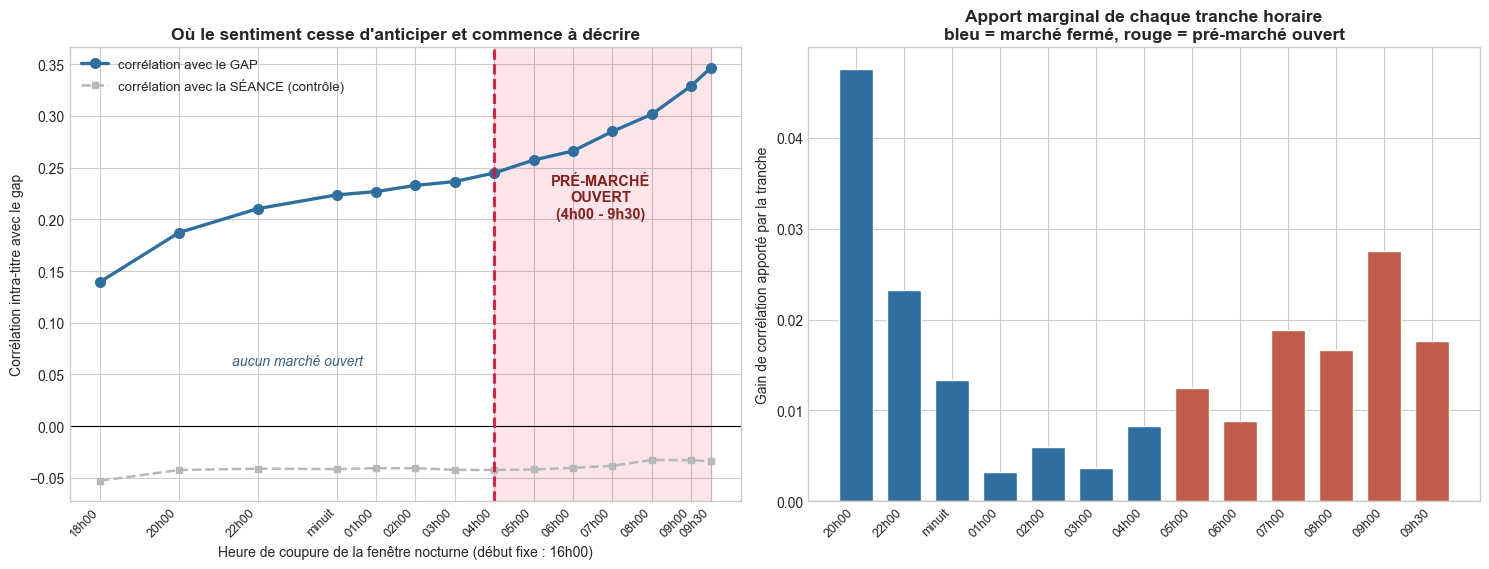

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.plot(C["coupure_h"], C["rho_gap_intra"], "o-", color="#2f6f9f", lw=2.4,
        markersize=7, label="corrélation avec le GAP")
ax.plot(C["coupure_h"], C["rho_seance_intra"], "s--", color="#b8b8b8", lw=1.8,
        markersize=5, label="corrélation avec la SÉANCE (contrôle)")
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(4, 9.5, color="crimson", alpha=0.11)
ax.axvline(4, color="crimson", ls="--", lw=2)
y1 = ax.get_ylim()[1]
ax.text(6.7, y1 * 0.55, "PRÉ-MARCHÉ\nOUVERT\n(4h00 - 9h30)", ha="center",
        fontsize=10.5, color="#8a1f1f", fontweight="bold")
ax.text(-1.0, y1 * 0.16, "aucun marché ouvert", ha="center", fontsize=10,
        color="#3a5f7f", style="italic")
ax.set_xticks(C["coupure_h"]); ax.set_xticklabels(C["heure"], rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Heure de coupure de la fenêtre nocturne (début fixe : 16h00)")
ax.set_ylabel("Corrélation intra-titre avec le gap")
ax.set_title("Où le sentiment cesse d'anticiper et commence à décrire",
             fontweight="bold", fontsize=12.5)
ax.legend(loc="upper left", fontsize=9.5)

ax = axes[1]
c2 = C.dropna(subset=["gain_rho"])
cols = ["#c05c4a" if h > 4 else "#2f6f9f" for h in c2["coupure_h"]]
ax.bar(range(len(c2)), c2["gain_rho"], color=cols, edgecolor="white", width=0.72)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(c2))); ax.set_xticklabels(c2["heure"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Gain de corrélation apporté par la tranche")
ax.set_title("Apport marginal de chaque tranche horaire\n"
             "bleu = marché fermé, rouge = pré-marché ouvert",
             fontweight="bold", fontsize=12.5)

plt.tight_layout()
plt.savefig(os.path.join(DOCS, "03bis_fig_courbe_coupures.png"), dpi=180, bbox_inches="tight")
plt.show()

In [17]:
def _v(t, col="rho_gap_intra"):
    return C.loc[C["coupure_h"] == t, col].iloc[0]

r0, r4, r95 = _v(0), _v(4), _v(9.5)
n4, n95 = _v(4, "n_messages"), _v(9.5, "n_messages")

print("=" * 78)
print("DÉCOMPOSITION DU SIGNAL PAR PHASE DE MARCHÉ")
print("=" * 78)
print(f"""
  16h00 -> minuit   (marché fermé)      rho = {r0:+.4f}
  16h00 -> 04h00    (marché fermé)      rho = {r4:+.4f}
  16h00 -> 09h30    (pré-marché inclus) rho = {r95:+.4f}

  PART ANTICIPATRICE (jusqu'à 4h00) ... {r4:+.4f}   soit {r4/r95*100:5.1f} % du total
  PART CONTEMPORAINE (4h00 -> 9h30) ... {r95-r4:+.4f}   soit {(r95-r4)/r95*100:5.1f} % du total

  Messages avant 4h00 : {n4:,.0f} sur {n95:,.0f}  ({n4/n95*100:.1f} %)

  LECTURE : la tranche 4h00-9h30 représente {100-n4/n95*100:.0f} % des messages mais apporte
  {(r95-r4)/r95*100:.0f} % de la corrélation. Cette disproportion est la signature d'une
  information CONTEMPORAINE et non ANTICIPATRICE.
""")
print("=" * 78)

with open(os.path.join(DOCS, "03bis_synthese.txt"), "w", encoding="utf-8") as f:
    f.write(f"rho_minuit={r0:.4f}\nrho_4h={r4:.4f}\nrho_9h30={r95:.4f}\n"
            f"part_anticipatrice={r4/r95:.4f}\npart_contemporaine={(r95-r4)/r95:.4f}\n"
            f"messages_avant_4h={n4:.0f}\nmessages_total={n95:.0f}\n")

DÉCOMPOSITION DU SIGNAL PAR PHASE DE MARCHÉ

  16h00 -> minuit   (marché fermé)      rho = +0.2236
  16h00 -> 04h00    (marché fermé)      rho = +0.2448
  16h00 -> 09h30    (pré-marché inclus) rho = +0.3467

  PART ANTICIPATRICE (jusqu'à 4h00) ... +0.2448   soit  70.6 % du total
  PART CONTEMPORAINE (4h00 -> 9h30) ... +0.1019   soit  29.4 % du total

  Messages avant 4h00 : 1,211,240 sur 1,708,692  (70.9 %)

  LECTURE : la tranche 4h00-9h30 représente 29 % des messages mais apporte
  29 % de la corrélation. Cette disproportion est la signature d'une
  information CONTEMPORAINE et non ANTICIPATRICE.



In [18]:
lignes = []
for tk in sorted(m["Ticker"].unique()):
    for t in [0, 4, 9.5]:
        sub = m[(m["h_rel"] <= t) & (m["Ticker"] == tk)]
        agg = (sub.groupby("date_cible")["score"].mean()
                  .rename("mu").reset_index().rename(columns={"date_cible": "Date"}))
        agg["Date"] = pd.to_datetime(agg["Date"])
        j = prix[prix["Ticker"] == tk].merge(agg, on="Date").dropna(subset=["mu", "gap"])
        lignes.append(dict(Ticker=tk, coupure=ETIQ[t], n=len(j),
                           rho=round(j["mu"].corr(j["gap"]), 4)))

R = pd.DataFrame(lignes).pivot(index="Ticker", columns="coupure", values="rho")
R = R[["minuit", "04h00", "09h30"]]
R["gain_4h_930"] = (R["09h30"] - R["04h00"]).round(4)
print("CORRÉLATION AVEC LE GAP, PAR TITRE ET PAR COUPURE")
print(R.round(4).to_string())
R.to_csv(os.path.join(DOCS, "03bis_coupures_par_ticker.csv"))
print(f"""
gain_4h_930 positif sur {int((R['gain_4h_930'] > 0).sum())} titres sur {len(R)}.
Si c'est 5 sur 5, la contamination par le pré-marché est un phénomène général
et non l'artefact d'une action particulière.
""")

CORRÉLATION AVEC LE GAP, PAR TITRE ET PAR COUPURE
coupure  minuit   04h00   09h30  gain_4h_930
Ticker                                      
AAPL     0.2682  0.2962  0.3856       0.0894
AMZN     0.2394  0.2677  0.3638       0.0961
META     0.2274  0.2489  0.3390       0.0901
NVDA     0.1904  0.2026  0.3258       0.1232
TSLA     0.2363  0.2577  0.3695       0.1118

gain_4h_930 positif sur 5 titres sur 5.
Si c'est 5 sur 5, la contamination par le pré-marché est un phénomène général
et non l'artefact d'une action particulière.

